# 03 · Latent-Space Preference Analysis (Exp3) — PTO only

Mass Mean Probe: per iteration the unit *preference direction* = mean(chosen − rejected) embeddings;
project words + MI-concept lists onto it to read what the policy prefers, and track the drift. Key
figures exported to `results/`. Set `RUN` to a PTO arm.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, figures
figures.set_style()
ARMS   = exp3.discover_arms()
SCORES = exp3.load_scores_long(ARMS)
PALETTE = figures.arm_palette(sorted(SCORES.arm.unique()))
METRICS = [m for m in exp3.QUESTIONNAIRE_ORDER if m in SCORES.questionnaire.unique()]
ORACLE_NOISE = 0.10   # oracle reproducibility band (~0.07-0.10 |Δ|, partial-conv EDA): min meaningful diff
print("arms on disk:", [(a.label, len(a.iters)) for a in ARMS])
print("scores_long:", SCORES.shape, "| arms scored:", sorted(SCORES.arm.unique()))
print("exports ->", exp3.RESULTS_DIR)

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 2), ('GRPO_LA0', 4), ('GRPO_LA5', 2)]
scores_long: (12096, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


In [2]:
from exp3 import pref
RUN = "PTO_LA0"
ARM = [a for a in ARMS if a.label == RUN][0]
assert ARM.method == "PTO", f"{RUN} is GRPO — no preference data; pick a PTO arm."
PAIRS = pref.add_text_features(training.load_pref_pairs([ARM])); EMB = pref.embed_pairs(PAIRS)
DIRS = pref.preference_direction_by_iter(EMB)
print(f"{RUN}: {len(PAIRS)} preference pairs over iters {sorted(DIRS)}")

PTO_LA0: 4935 preference pairs over iters [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 1 · Probe quality per iteration
`wins_correct` ≫ 0.5 means the learned direction really separates chosen from rejected.

,train_iter,n,wins_correct,mean_gap,mean_margin
0,1,782,0.6509,0.0517,0.3217
1,2,618,0.6553,0.0629,0.2988
2,3,620,0.6097,0.0493,0.2946
3,4,536,0.6511,0.0510,0.2690
4,5,483,0.6605,0.0493,0.2812
5,6,475,0.6926,0.0605,0.2673
6,7,400,0.6825,0.0513,0.2718
7,8,379,0.6623,0.0629,0.2491
8,9,361,0.7175,0.0594,0.2657
9,10,281,0.7082,0.0624,0.2667


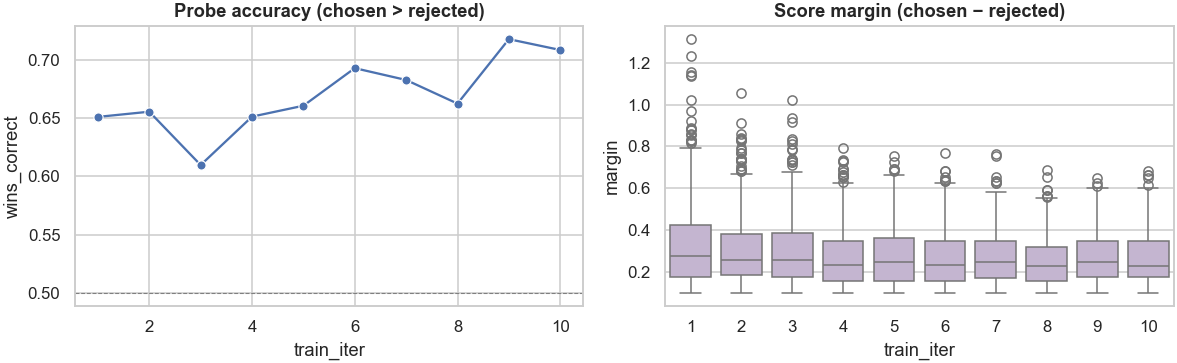

In [3]:
PQ = pref.probe_quality_by_iter(EMB, DIRS); display(PQ.round(4))
exp3.save_table(PQ.round(4), f"{RUN}_pref_probe_quality", caption=f"{RUN}: per-iteration preference-probe accuracy (wins_correct), mean projection gap, and score margin.")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.lineplot(PQ, x="train_iter", y="wins_correct", marker="o", ax=ax[0]); ax[0].axhline(0.5, color="grey", ls="--", lw=.7); ax[0].set_title("Probe accuracy (chosen > rejected)")
sns.boxplot(PAIRS, x="train_iter", y="margin", color="#c5b0d5", ax=ax[1]); ax[1].set_title("Score margin (chosen − rejected)")
fig.tight_layout(); exp3.save_fig(fig, f"{RUN}_pref_probe", caption=f"{RUN}: probe accuracy + score margin per training iteration."); plt.show()

## 2 · Word ranking — which words the policy prefers

Top CHOSEN-aligned:
succeed, courageous, readiness, accomplish, steps, courage, fearless, successful, success, promising, resist, inspirational, step, achieving, stepping, bravery, fail, impressed, motivate, perseverance

Top REJECTED-aligned:
chat, conversation, discussing, conversations, session, typically, wondering, talking, sessions, regarding, bedtime, curious, specifically, mind, usually, com, use, rather, regularly, date


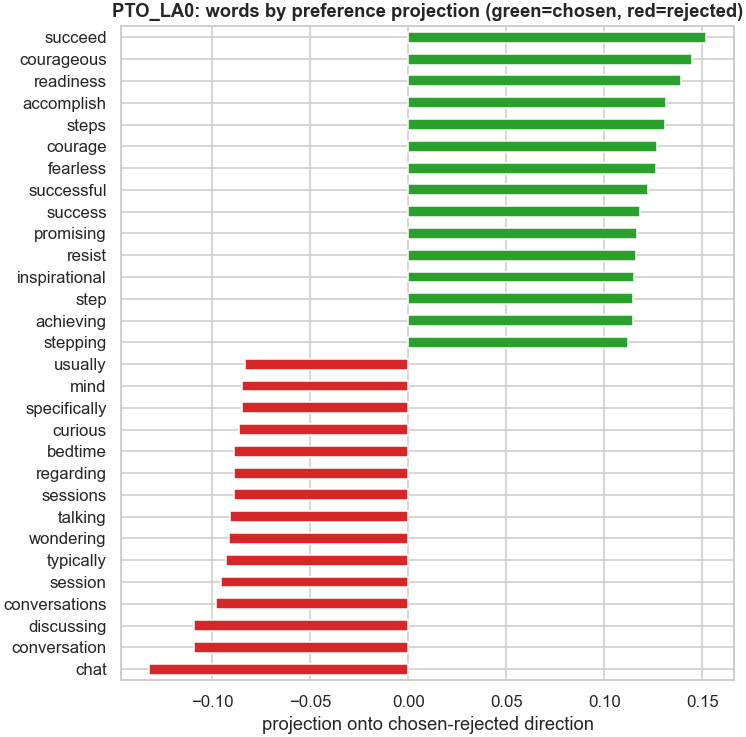

In [4]:
words, wmat = pref.embed_vocab(pref.build_vocab(PAIRS, top_n=3000)); WP = pref.word_projection(words, wmat, DIRS)
print("Top CHOSEN-aligned:"); print(", ".join(WP.sort_values("mean", ascending=False).head(20).index))
print("\nTop REJECTED-aligned:"); print(", ".join(WP.sort_values("mean").head(20).index))
top = WP.sort_values("mean", ascending=False).head(15).index.tolist() + WP.sort_values("mean").head(15).index.tolist()
s = WP.loc[top, "mean"].sort_values()
fig, ax = plt.subplots(figsize=(7, 7)); s.plot.barh(ax=ax, color=(s>0).map({True:"#2ca02c", False:"#d62728"}))
ax.set_title(f"{RUN}: words by preference projection (green=chosen, red=rejected)"); ax.set_xlabel("projection onto chosen-rejected direction")
fig.tight_layout(); exp3.save_fig(fig, "pref_word_ranking", caption=f"{RUN}: top words aligned with chosen (green) vs rejected (red) preference direction (pooled over iters)."); plt.show()

## 3 · MI-concept projection across iterations
Marginal signal: a behavior the policy has already saturated stops discriminating chosen from rejected (so a falling score can mean 'already adopted'). Read with `02`'s absolute behavior counts.

category,Affirmation,ChangeTalk,OpenQuestion,Reflection,SustainTalk,TherapistActions
train_iter,,,,,,
1,0.086,0.034,-0.006,-0.014,0.016,0.066
2,0.030,-0.072,-0.086,-0.062,-0.019,-0.019
3,-0.027,-0.057,-0.044,-0.068,-0.017,-0.032
4,0.172,0.155,0.124,0.127,0.140,0.144
5,0.039,0.000,-0.060,-0.040,0.039,0.002
6,0.111,0.072,-0.001,0.026,0.092,0.046
7,0.123,0.068,0.048,0.041,0.112,0.071
8,0.036,0.035,-0.028,-0.009,-0.018,-0.020
9,0.069,0.001,-0.026,-0.018,0.042,0.020


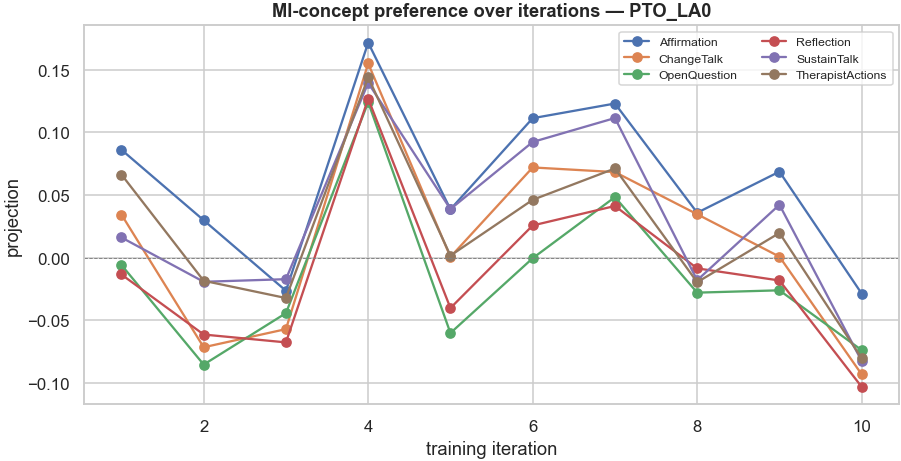

In [5]:
CAT = pref.category_projection(DIRS); piv = CAT.pivot(index="train_iter", columns="category", values="score")
display(piv.round(3)); exp3.save_table(piv.round(4).reset_index(), f"{RUN}_pref_MI_concepts", caption=f"{RUN}: MI-concept word-list projection onto the per-iteration preference direction.")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for catname in piv.columns: ax.plot(piv.index, piv[catname], marker="o", label=catname)
ax.axhline(0, color="grey", lw=.6, ls="--"); ax.set_xlabel("training iteration"); ax.set_ylabel("projection")
ax.set_title(f"MI-concept preference over iterations — {RUN}"); ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); exp3.save_fig(fig, f"{RUN}_pref_MI_concepts", caption=f"{RUN}: MI-concept projection onto the preference direction across iterations."); plt.show()

## 4 · Evolutionary trajectory + K0-vs-K5 stub

In [6]:
iters = sorted(DIRS); lo, hi = iters[0], iters[-1]; WP["shift"] = WP[hi] - WP[lo]
print(f"Preference ROSE most ({lo}->{hi}):"); print(", ".join(WP.sort_values("shift", ascending=False).head(20).index))
print(f"\nPreference FELL most:"); print(", ".join(WP.sort_values("shift").head(20).index))
pto5 = [a for a in ARMS if a.label=="PTO_LA5" and len(training.load_pref_pairs([a]))]
print("\nPTO_LA5 preference pairs available:", bool(pto5), "(K0-vs-K5 comparison pending until scored)")

Preference ROSE most (1->10):
cancer, patients, unhealthy, talk, cigarette, conversation, exhale, lbs, talked, nicotine, mouth, healthiest, lungs, lung, talking, warrior, smoker, reassurance, tone, stressed

Preference FELL most:
achieving, exploring, nurture, develop, successful, finding, motivates, motivate, satisfying, fulfilling, motivating, transition, improving, find, explore, learnings, nurturing, motivations, exploration, developing

PTO_LA5 preference pairs available: True (K0-vs-K5 comparison pending until scored)


## 5 · Takeaways
- _(is the preference direction increasingly affirmation/empowerment-aligned? which words drive it?)_